In [1]:
# %autoreload 0

import pickle

import sys
from pathlib import Path

%cd /well/rittscher/users/mju725/trimodal_alignment

project_root = Path.cwd()
sys.path.insert(0, str(project_root))

import re
import torch

from common_functions import (
    create_multisample_metadata,
    fuse_gene_cell_type_vectors,
    load_samples,
    split_checkerboard_xenium,
)
from training_functions import load_trimodal_inputs
from retrieval_functions import (
    plot_spatial_heatmap,
    visualize_search_by_example,
    visualize_text_search,
)

import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns
import numpy as np

import random

from openai import OpenAI
import matplotlib.collections

client = OpenAI()

/well/rittscher/users/mju725/conda/skylake/envs/histomotif_clean/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/exafs1/well/rittscher/users/mju725/trimodal_alignment


/well/rittscher/users/mju725/conda/skylake/envs/histomotif_clean/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Let's load the models and their resulting performance - trained in the final_models.py script.

In [5]:
lung_dir =  "/well/rittscher/users/mju725/trimodal_alignment_objects/lung"
figures_dir = "/well/rittscher/users/mju725/trimodal_alignment_objects/figures"

prostate_dir = "/well/rittscher/users/mju725/trimodal_alignment_objects/prostate"
models_output_dir = "/well/rittscher/users/mju725/trimodal_alignment_objects/models/"

In [3]:
samples_lung = load_samples(lung_dir)
samples_prostate = load_samples(prostate_dir)

In [2]:
def summarize_performance(results):
    aliases = {
        # QUERY-ST
        "image_rna": "image_rna",
        "rna_image": "rna_image",
        "image_text": "image_text",
        "text_image": "text_image",
        "rna_text": "rna_text",
        "text_rna": "text_rna",

        # HESCAPE
        "image_to_gene": "image_rna",
        "gene_to_image": "rna_image",
    }

    direction_labels = {
        "image_rna": "Image->RNA",
        "rna_image": "RNA->Image",
        "image_text": "Image->Text",
        "text_image": "Text->Image",
        "rna_text": "RNA->Text",
        "text_rna": "Text->RNA",
    }

    pairs = {
        "Image<->RNA": ("image_rna", "rna_image"),
        "Image<->Text": ("image_text", "text_image"),
        "RNA<->Text": ("rna_text", "text_rna"),
    }

    metrics = [
        "R@1",
        "R@5",
        "R@10",
        "MRR",
        "median_rank",
        "mean_rank",
    ]

    rows = []

    for split, split_results in results.items():
        if not isinstance(split_results, dict):
            continue

        # Lung entries such as patient__tissue are later averaged by patient.
        unit = str(split).split("__", 1)[0]

        canonical = {
            aliases[key]: value
            for key, value in split_results.items()
            if key in aliases and isinstance(value, dict)
        }

        # Directional results
        for direction, direction_metrics in canonical.items():
            for metric in metrics:
                if metric in direction_metrics:
                    rows.append({
                        "Fold": unit,
                        "Split": str(split),
                        "Task": direction_labels[direction],
                        "Metric": metric,
                        "Value": float(direction_metrics[metric]),
                    })

        # Bidirectional averages within each split
        for pair_label, (forward, reverse) in pairs.items():
            if forward not in canonical or reverse not in canonical:
                continue

            for metric in metrics:
                if (
                    metric in canonical[forward]
                    and metric in canonical[reverse]
                ):
                    value = np.mean([
                        canonical[forward][metric],
                        canonical[reverse][metric],
                    ])

                    rows.append({
                        "Fold": unit,
                        "Split": str(split),
                        "Task": pair_label,
                        "Metric": metric,
                        "Value": float(value),
                    })

    if not rows:
        raise ValueError(
            "No directional metrics found. Pass the raw results dictionary, "
            "not hescape_comparison_results_dict."
        )

    split_results_df = pd.DataFrame(rows)

    # Average multiple tissues belonging to the same Lung patient.
    fold_results = (
        split_results_df
        .groupby(["Fold", "Task", "Metric"], as_index=False)["Value"]
        .mean()
    )

    summary_results = (
        fold_results
        .groupby(["Task", "Metric"], as_index=False)
        .agg(
            Mean=("Value", "mean"),
            SD=("Value", "std"),
            Median=("Value", "median"),
            N=("Value", "count"),
        )
    )

    return fold_results, summary_results

In [1]:
print("test")

test


# Lung

Let's load the retrieval results of the full (trimodal) and bimodal models.

In [5]:
# Full model - Lung
with open(f"{lung_dir}/lopo_objects/lopo_lung_final_results.pkl", "rb") as f:
        results_lopo_lung = pickle.load(f)
        
with open(f"{lung_dir}/lopo_objects/lopo_lung_final_bimodal_results.pkl", "rb") as f:
        results_lopo_lung_bimodal = pickle.load(f)

In [37]:
lopo_results_lung, summary_results_lung = summarize_performance(results_lopo_lung)
lopo_results_lung_bimodal, summary_results_lung_bimodal = summarize_performance(results_lopo_lung_bimodal)

In [39]:
summary_results_lung

,Task,Metric,Mean,SD,Median,N
0,Image->RNA,MRR,0.225933,0.103409,0.223322,31
1,Image->RNA,R@1,0.127400,0.072178,0.117347,31
2,Image->RNA,R@10,0.426502,0.173378,0.436975,31
3,Image->RNA,R@5,0.317589,0.148707,0.310584,31
4,Image->RNA,mean_rank,60.195706,55.699085,46.934260,31
5,Image->RNA,median_rank,31.403226,55.510723,15.000000,31
6,Image->Text,MRR,0.140113,0.060995,0.131431,31
7,Image->Text,R@1,0.065614,0.035686,0.065889,31
8,Image->Text,R@10,0.291514,0.124931,0.302149,31
9,Image->Text,R@5,0.193522,0.090897,0.176991,31


In [40]:
summary_results_lung_bimodal

,Task,Metric,Mean,SD,Median,N
0,Image->RNA,MRR,0.235652,0.109593,0.229779,31
1,Image->RNA,R@1,0.134964,0.076526,0.131513,31
2,Image->RNA,R@10,0.444150,0.186819,0.451681,31
3,Image->RNA,R@5,0.332335,0.158699,0.318277,31
4,Image->RNA,mean_rank,58.563450,57.465857,40.223714,31
5,Image->RNA,median_rank,31.000000,55.700539,14.000000,31
6,Image<->RNA,MRR,0.235241,0.107773,0.231241,31
7,Image<->RNA,R@1,0.134318,0.074929,0.128676,31
8,Image<->RNA,R@10,0.442961,0.184542,0.438675,31
9,Image<->RNA,R@5,0.333140,0.156056,0.325173,31


As evident, the trimodal model preserves very similar Image<->RNA performance to the bimodal model while enabling the trimodal alignment.

Now let's load the HESCAPE comparison results. The QUERY-ST model used here is a smaller capacity controlled model (smaller hidden width to match parameter number of the HESCAPE configuration).

In [6]:
with open(f"{lung_dir}/lopo_objects/lopo_lung_matched_bimodal_hidden128_results.pkl", "rb") as f:
        results_lopo_lung_gene_vecs_bimodal_hidden128 = pickle.load(f)
        
with open(f"{lung_dir}/hescape_comparison/server_hescape_optimizer_matched_bs256_full/server_hescape_optimizer_matched_bs256_full_official_hescape_results.pkl", 'rb') as f:
        results_hescape_comparison = pickle.load(f)   

In [14]:
lopo_results_matched_gene_vecs_bimodal_hidden128, summary_results_matched_gene_vecs_bimodal_hidden128 = summarize_performance(results_lopo_lung_gene_vecs_bimodal_hidden128)
lopo_results_hescape, summary_results_hescape =  summarize_performance(results_hescape_comparison)

In [43]:
summary_results_matched_gene_vecs_bimodal_hidden128

,Task,Metric,Mean,SD,Median,N
0,Image->RNA,MRR,0.140677,0.069423,0.140204,31
1,Image->RNA,R@1,0.064763,0.038848,0.066702,31
2,Image->RNA,R@10,0.294729,0.144035,0.291590,31
3,Image->RNA,R@5,0.199371,0.107040,0.193292,31
4,Image->RNA,mean_rank,90.249515,62.639483,74.977629,31
5,Image->RNA,median_rank,53.129032,62.399648,31.000000,31
6,Image<->RNA,MRR,0.137458,0.067278,0.137023,31
7,Image<->RNA,R@1,0.062867,0.037699,0.061521,31
8,Image<->RNA,R@10,0.287659,0.138754,0.290139,31
9,Image<->RNA,R@5,0.194090,0.103138,0.189215,31


In [44]:
summary_results_hescape

,Task,Metric,Mean,SD,Median,N
0,Image->RNA,R@1,0.040856,0.025720,0.042493,31
1,Image->RNA,R@10,0.223717,0.119771,0.225212,31
2,Image->RNA,R@5,0.143983,0.083701,0.154362,31
3,Image->RNA,mean_rank,111.289366,69.905127,93.276207,31
4,Image->RNA,median_rank,72.790323,70.735514,45.000000,31
5,Image<->RNA,R@1,0.037943,0.024362,0.041321,31
6,Image<->RNA,R@10,0.208842,0.116511,0.215393,31
7,Image<->RNA,R@5,0.133655,0.079237,0.148725,31
8,Image<->RNA,mean_rank,117.805072,74.600436,89.774082,31
9,Image<->RNA,median_rank,80.887097,77.822738,54.000000,31


Let's compared patient-level bidirectional Image↔RNA R@10 between HESCAPE and the capacity-controlled QUERY-ST backbone across 31 held-out Lung patients.

In [34]:
from scipy.stats import wilcoxon

hescape = (
    lopo_results_hescape
    .query("Task == 'Image<->RNA' and Metric == 'R@10'")
    [["Fold", "Value"]]
    .rename(columns={"Value": "hescape"})
)

queryst = (
    lopo_results_matched_gene_vecs_bimodal_hidden128
    .query("Task == 'Image<->RNA' and Metric == 'R@10'")
    [["Fold", "Value"]]
    .rename(columns={"Value": "queryst"})
)

paired = hescape.merge(
    queryst,
    on="Fold",
    how="inner",
    validate="one_to_one"
)

paired["difference"] = paired["queryst"] - paired["hescape"]

stat, p = wilcoxon(
    paired["queryst"],
    paired["hescape"],
    alternative="two-sided"
)

print(f"N patients: {len(paired)}")
print(f"HESCAPE mean R@10: {paired['hescape'].mean():.3f}")
print(f"QUERY-ST mean R@10: {paired['queryst'].mean():.3f}")
print(f"Mean paired difference: {paired['difference'].mean():.3f}")
print(f"Median paired difference: {paired['difference'].median():.3f}")
print(f"QUERY-ST better in {(paired['difference'] > 0).sum()}/{len(paired)} patients")
print(f"Wilcoxon statistic: {stat:.3f}")
print(f"p-value: {p:.6g}")

N patients: 31
HESCAPE mean R@10: 0.209
QUERY-ST mean R@10: 0.288
Mean paired difference: 0.079
Median paired difference: 0.072
QUERY-ST better in 29/31 patients
Wilcoxon statistic: 4.000
p-value: 6.51926e-09


The bimodal, capacity-controlled QUERY-ST achieved higher mean R@10 (0.288 vs. 0.209), with a mean paired improvement of 0.079 and higher performance in 29/31 patients. The difference was significant by a two-sided paired Wilcoxon signed-rank test (p = 6.5 × 10⁻⁹).

In [49]:
tissues = results_hescape_comparison.keys()
hescape_comparison_results_dict = {}

for tissue in tissues:
    tissue_results = {}
    tissue_results['gene_vecs_bimodal_hidden128'] = (results_lopo_lung_gene_vecs_bimodal_hidden128[tissue]['image_rna']['R@10'] + results_lopo_lung_gene_vecs_bimodal_hidden128[tissue]['rna_image']['R@10'])/2
    tissue_results['hescape'] = (results_hescape_comparison[tissue]['image_to_gene']['R@10'] + results_hescape_comparison[tissue]['gene_to_image']['R@10'])/2
    
    hescape_comparison_results_dict[tissue] = tissue_results

In [51]:
def plot_lung_models_comparison(
    hescape_comparison_results_dict,
    figures_dir,
    out_name="hescape_lung_comparison",
):
    rows = []
    for split, results in hescape_comparison_results_dict.items():
        patient = split.split("__", 1)[0]
        for model, r10 in results.items():
            rows.append({
                "Patient": patient,
                "Model": model,
                "R@10": float(r10),
            })

    # One observation per patient, averaging tissues when necessary.
    patient_df = (
        pd.DataFrame(rows)
        .groupby(["Patient", "Model"], as_index=False)["R@10"]
        .mean()
    )

    order = [
        "hescape",
        "gene_vecs_bimodal_hidden128",
    ]
    labels = {
        "hescape": "HESCAPE",
        "gene_vecs_bimodal_hidden128": "Ours\ncapacity-matched",
    }
    palette = {
        "hescape": "#ffb785",
        "gene_vecs_bimodal_hidden128": "#f86700"
    }

    sns.set_theme(style="white", context="paper")
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 9,
        "ytick.labelsize": 10,
        "figure.dpi": 300,
    })

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.boxplot(
        data=patient_df, x="Model", y="R@10", order=order,
        palette=palette, width=0.55, fliersize=0, linewidth=1.1, ax=axes[0],
    )
    sns.stripplot(
        data=patient_df, x="Model", y="R@10", order=order,
        color="#222222", alpha=0.38, jitter=0.16, size=3.2, ax=axes[0],
    )
    axes[0].set_xticklabels([labels[x] for x in order])
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Image<->RNA R@10")
    axes[0].set_ylim(0, 1)

    wide = patient_df.pivot(index="Patient", columns="Model", values="R@10")
    x = wide["hescape"]
    y = wide["gene_vecs_bimodal_hidden128"]
    limit = np.ceil(max(x.max(), y.max()) * 10) / 10 + 0.02

    axes[1].scatter(x, y, s=34, color="#ff8834", alpha=0.8, edgecolor="white")
    axes[1].plot([0, limit], [0, limit], "--", color="#777777", linewidth=1.2)
    axes[1].set(xlim=(0, limit), ylim=(0, limit))
    axes[1].set_aspect("equal", adjustable="box")
    axes[1].set_xlabel("HESCAPE R@10")
    axes[1].set_ylabel("Ours, capacity-matched R@10")
    axes[1].text(
        0.7, 0.2,
        f"Median:\nHESCAPE: {x.median():.3f}\nOurs matched: {y.median():.3f}",
        transform=axes[1].transAxes, va="top", fontsize=9,
    )

    for ax in axes:
        ax.grid(axis="y", linewidth=0.6, alpha=0.3)
    sns.despine()
    fig.tight_layout()

    figures_dir = Path(figures_dir)
    figures_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(figures_dir / f"{out_name}.pdf", bbox_inches="tight")
    fig.savefig(figures_dir / f"{out_name}.svg", bbox_inches="tight")
    plt.show()

    return patient_df, wide

/tmp/ipykernel_587629/673044383.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_587629/673044383.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([labels[x] for x in order])


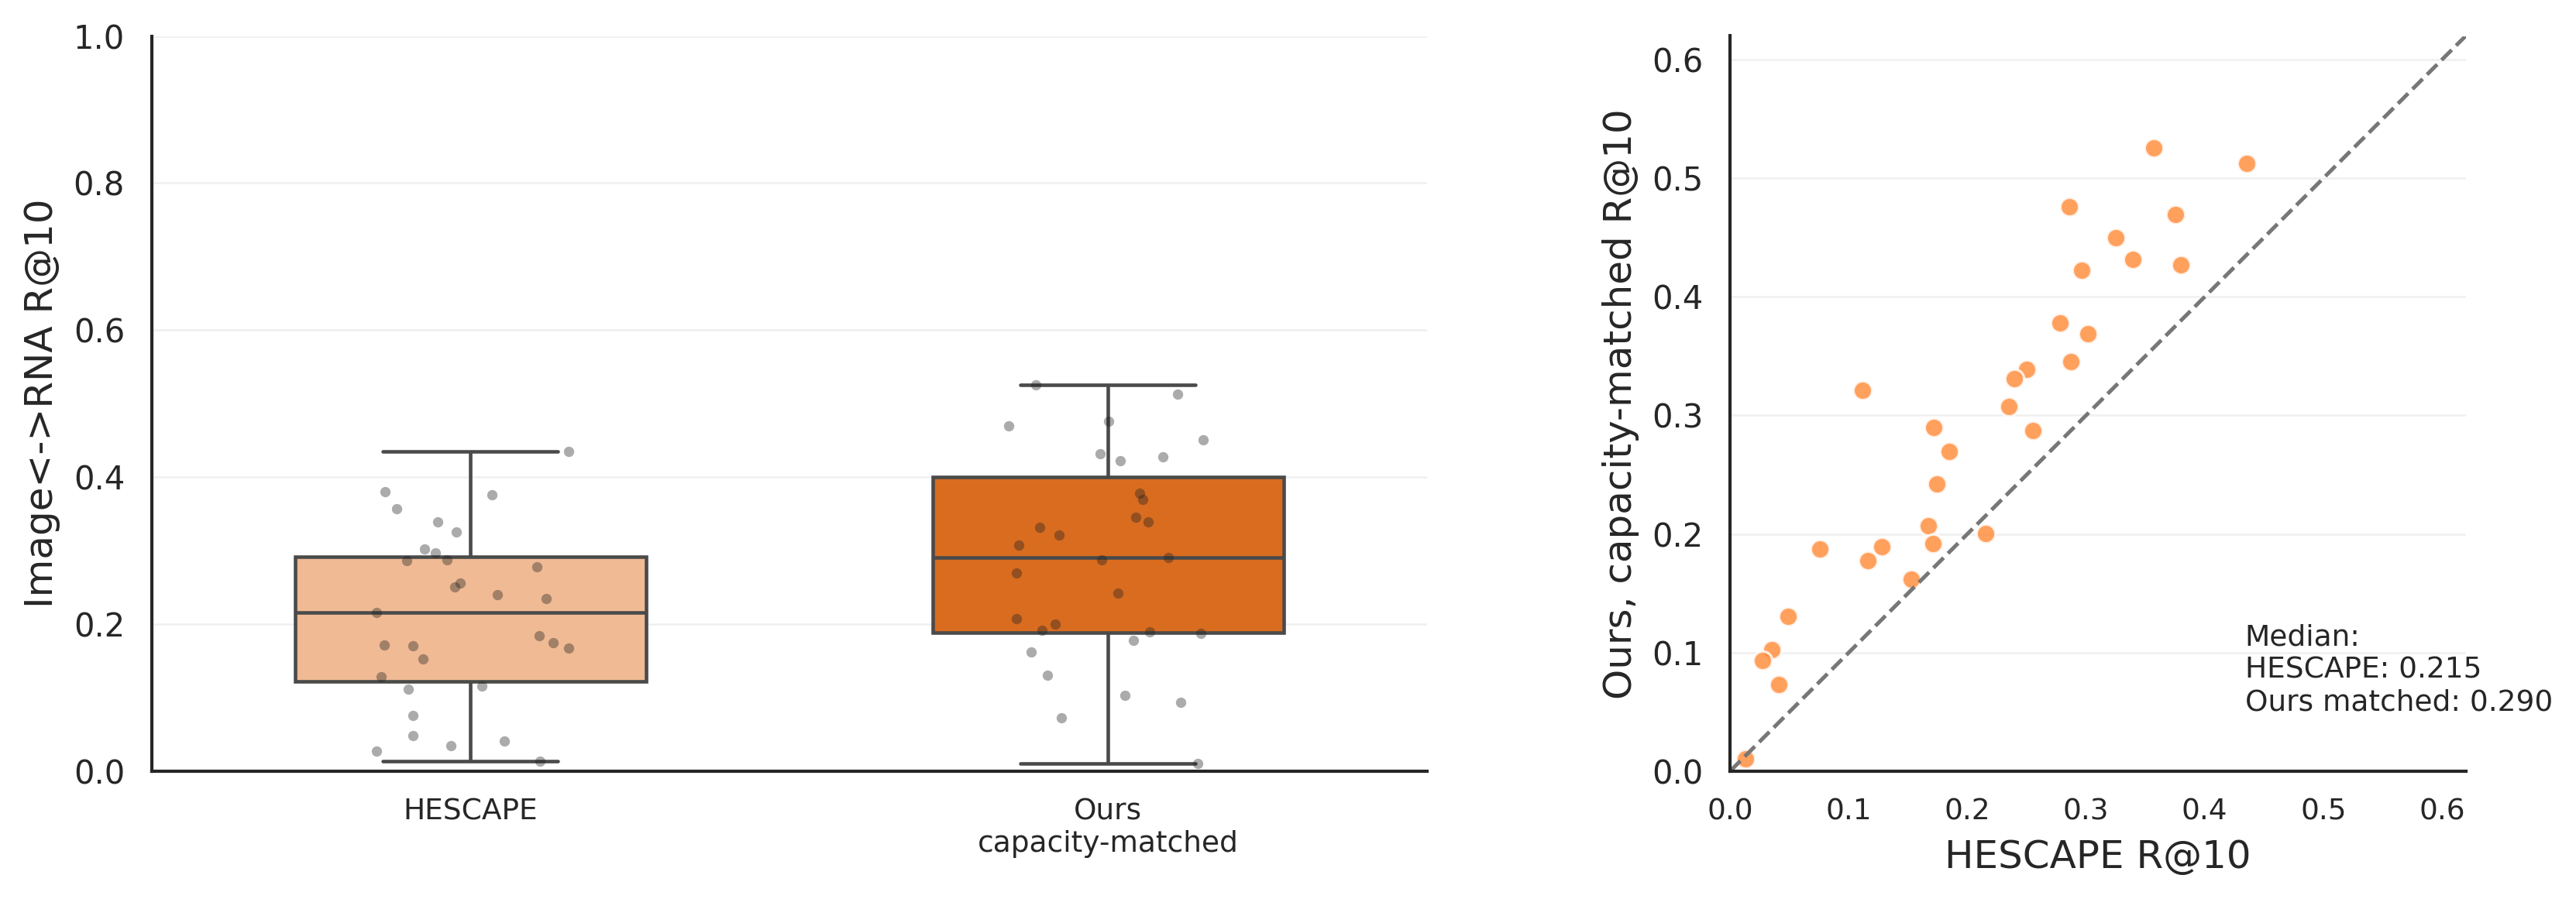

In [52]:
patient_df, paired_df = plot_lung_models_comparison(
    hescape_comparison_results_dict,
    figures_dir,
)

As evident our Image<->RNA backbone is competitive with HESCAPE under matching configurations.

Now let's load the model and the inputs.

In [53]:
with open(f"/{lung_dir}/lopo_objects/lopo_lung_final_models.pkl", "rb") as f:
        models_lopo_lung = pickle.load(f)

In [54]:
uni_embeddings_lung, cell_vectors_lung, master_gene_vectors_lung, master_text_embeddings_lung, ground_truth_openai_dict_lung = load_trimodal_inputs(samples_lung, lung_dir)

common_keys_fused_lung = sorted(list(set(cell_vectors_lung.keys()) & set(master_gene_vectors_lung['full'].keys())))
master_fused_vectors_lung = fuse_gene_cell_type_vectors(common_keys_fused_lung, cell_vectors_lung, master_gene_vectors_lung['full'])

We will examine the VUILD107 patient - as this is annotated in the lung study by the authors. We will do a search for hypercellular mesenchymal region dominated by activated fibrotic fibroblasts and plasma cells.

Parsing metadata for 28362 patches...
932


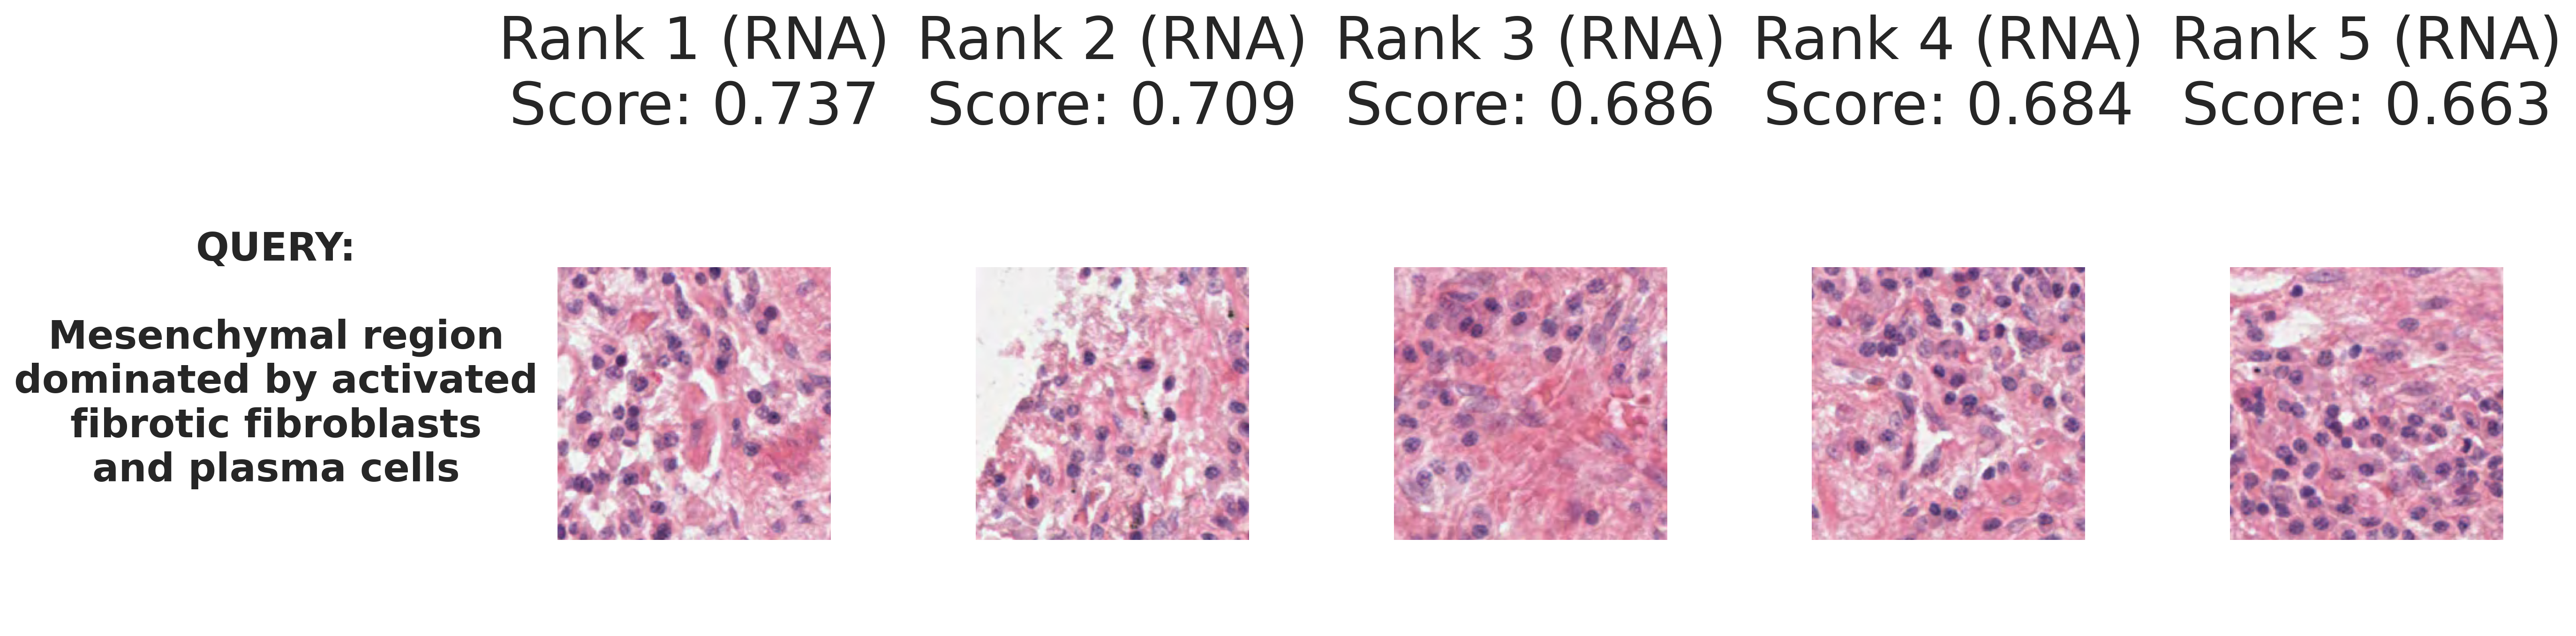

In [81]:
SAMPLE_ID = "VUILD107"

meta_df_lung = create_multisample_metadata(list(uni_embeddings_lung.keys()))

filtered_uni_keys = [key for key in uni_embeddings_lung.keys() if key.startswith(SAMPLE_ID)]
filtered_fused_keys = [key for key in master_fused_vectors_lung.keys() if key.startswith(SAMPLE_ID)]
filtered_text_keys = [key for key in master_text_embeddings_lung['level_3_1_2'].keys() if key.startswith(SAMPLE_ID)]

common_keys = sorted(list(
    set(filtered_uni_keys) & 
    set(filtered_fused_keys) &
    set(filtered_text_keys)
))

print(len(filtered_fused_keys))

chosen_model_lung = models_lopo_lung[SAMPLE_ID]
X_img_lung = np.stack([uni_embeddings_lung[k] for k in common_keys]).astype(np.float32)
X_rna_lung = np.stack([master_fused_vectors_lung[k] for k in common_keys]).astype(np.float32)

# Embed them in the shared latent space using the trimodal model
chosen_model_lung.eval()
with torch.no_grad():
    H_img_lung = chosen_model_lung.embed_batch(X_img_lung, branch="img")
    H_rna_lung = chosen_model_lung.embed_batch(X_rna_lung, branch="rna")

# meta_df_sample must be sorted exactly like common_keys
meta_df_sample = meta_df_lung[meta_df_lung['unique_key'].isin(common_keys)].copy()
meta_df_sample = meta_df_sample.set_index('unique_key').reindex(common_keys).reset_index()

query_lung = "Mesenchymal region dominated by activated fibrotic fibroblasts and plasma cells"

gt_dict_lung_query = visualize_text_search(
    client, 
    chosen_model_lung, 
    query_lung, 
    H_rna_lung,
    meta_df_sample['unique_key'].tolist(),
    meta_df_sample, 
    lung_dir, 
    ground_truth_level=ground_truth_openai_dict_lung["level_1_2_3"],
    sample_id_col="tissue",
    target_modality="rna",
    k=5, 
    microns_size=112,
    save_path=figures_dir
)


In [29]:
geojson_dir = "/well/rittscher/users/mju725/trimodal_alignment_objects/lung/author_annotations"

Computing similarity for: 'Mesenchymal region dominated by activated fibrotic fibroblasts and plasma cells'...


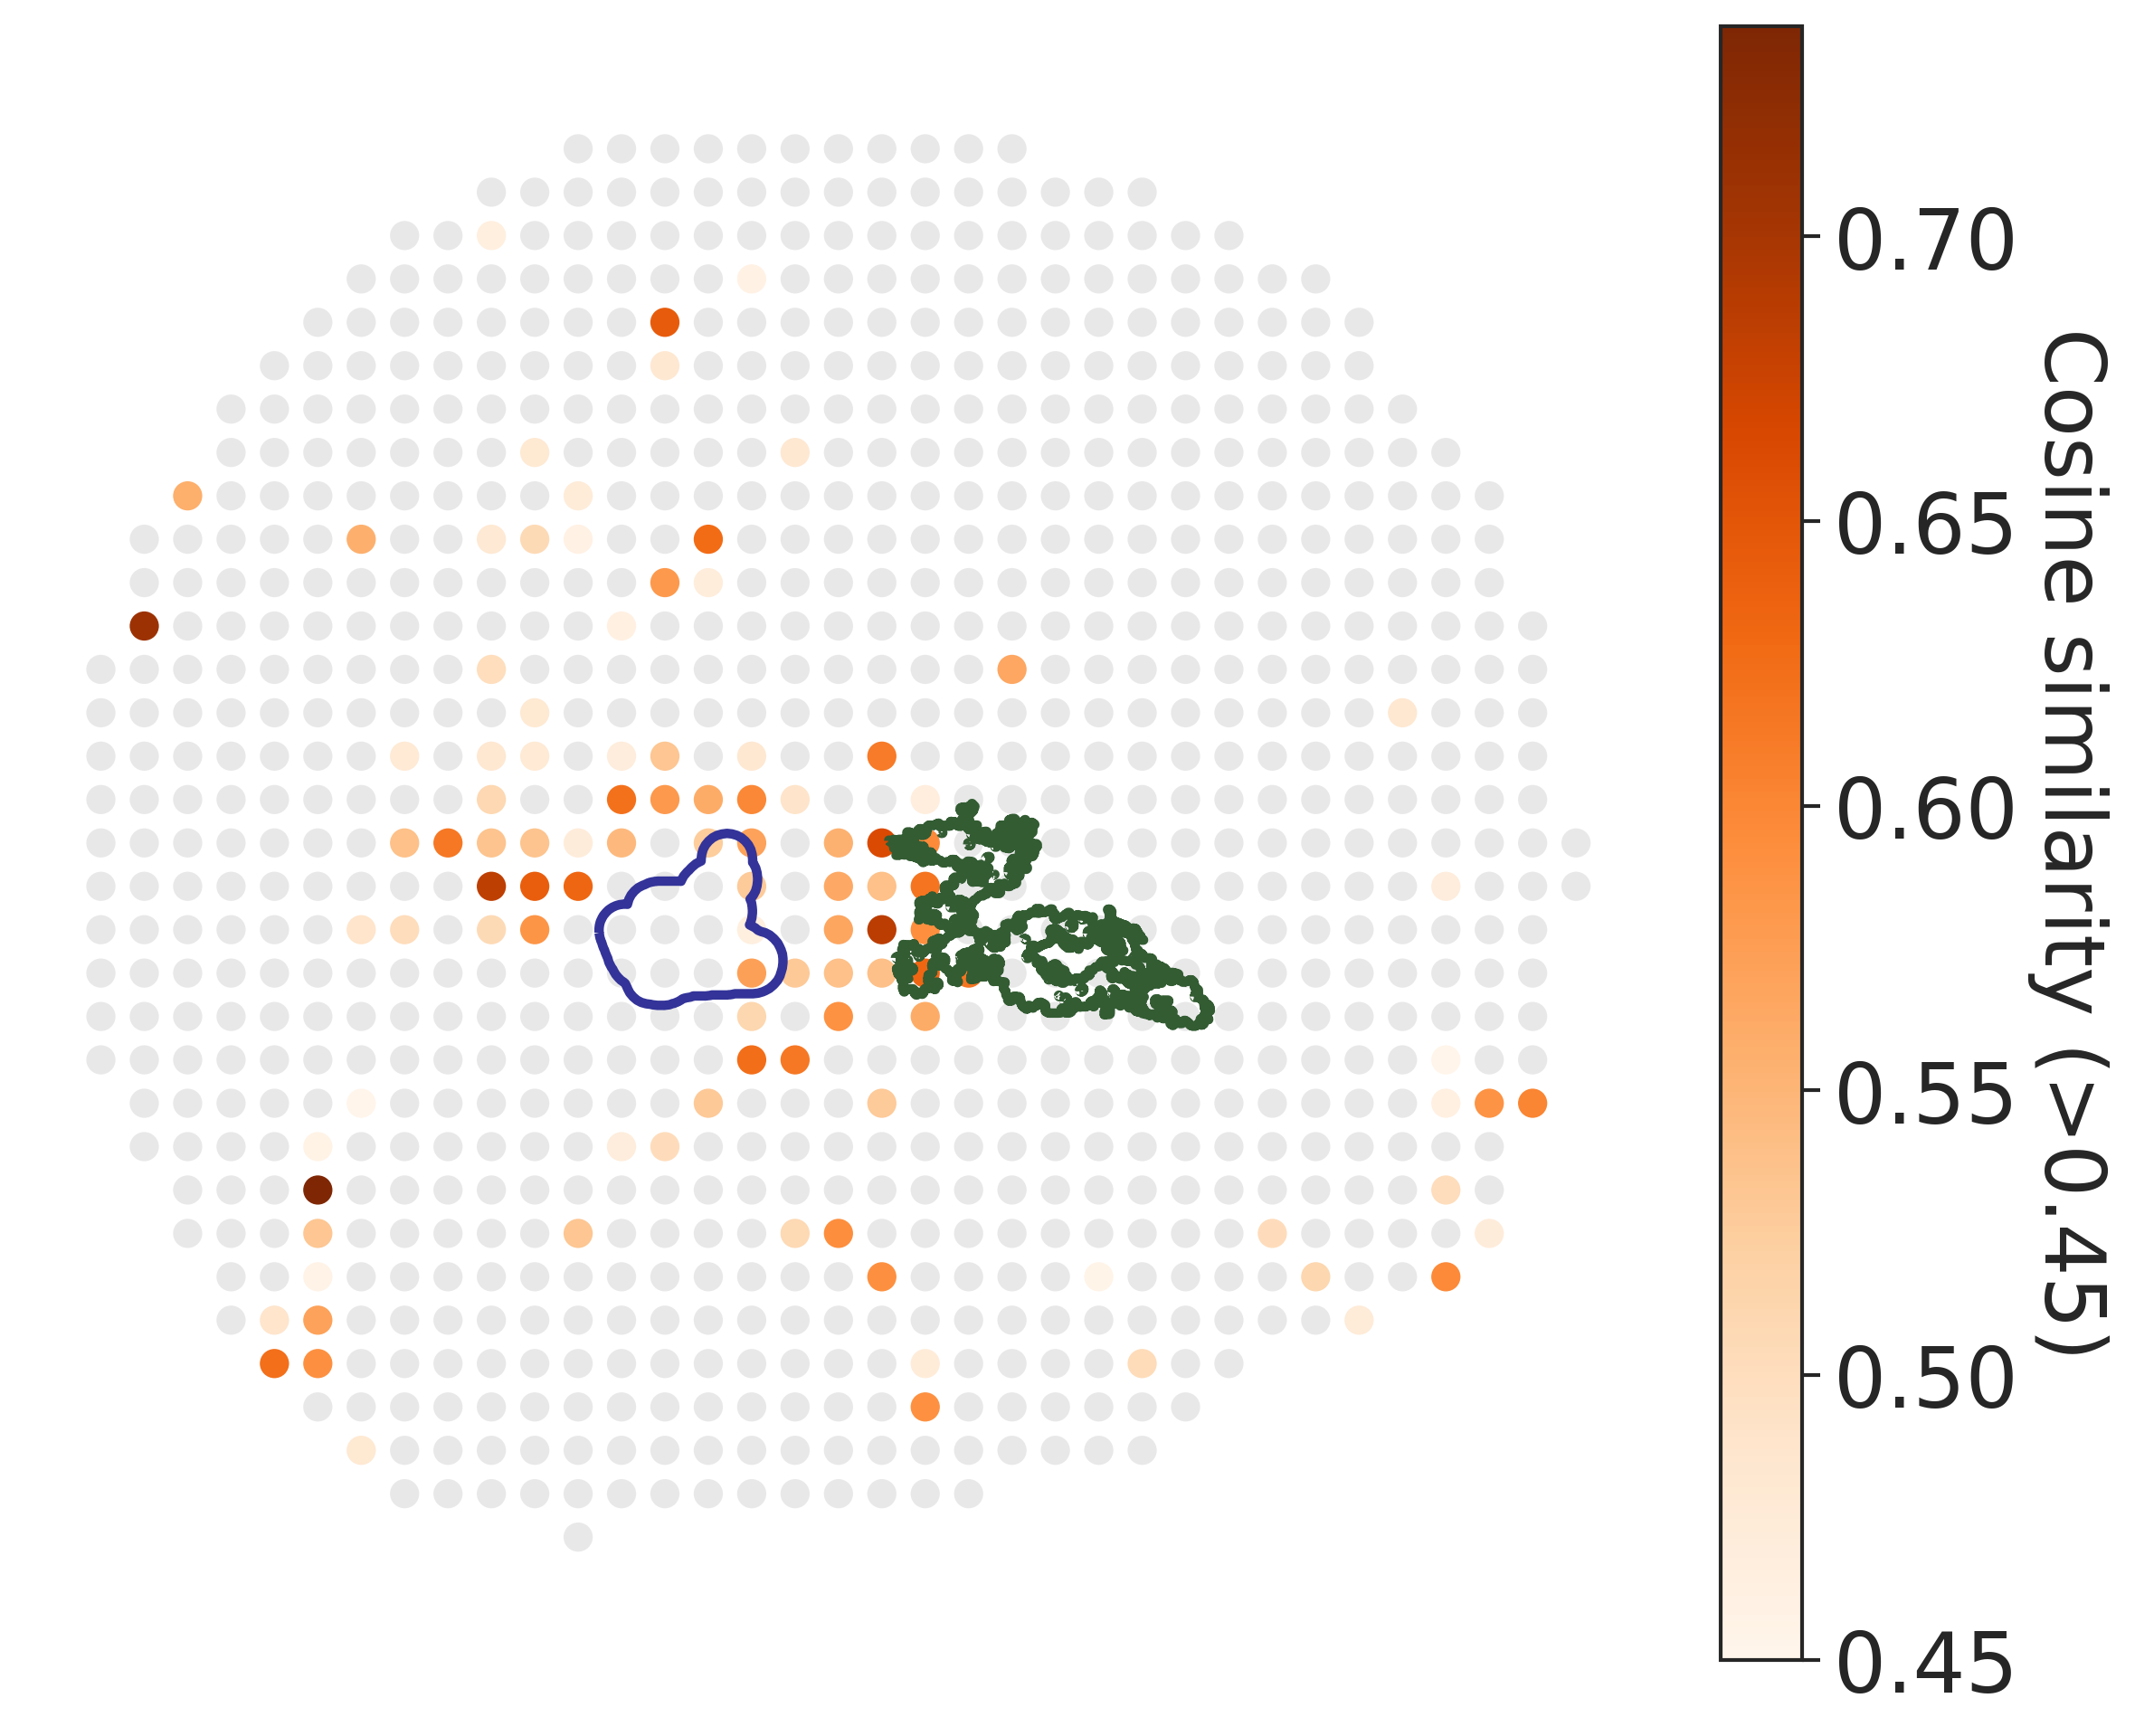

(<Figure size 2400x2400 with 2 Axes>, <Axes: >)

In [88]:
plot_spatial_heatmap(
    client=client,
    query_text=query_lung,
    model=chosen_model_lung,
    target_emb_matrix=H_rna_lung,
    meta_df=meta_df_sample,
    sample_id="VUILD107MA",
    target_modality="rna",
    threshold=0.45,
    geojson_dir="/well/rittscher/users/mju725/trimodal_alignment_objects/lung/author_annotations",
    flip_annotation_y=True,
    save_path=f"{figures_dir}/heatmap_query_lung_VUILD107MA_annotations",
    cmap="Oranges",
    point_size=60
)

The highlighted region largely concentrates at a region bridging author annotations of Mixed Inflammation and Severe Fibrosis. 

# Prostate

In [21]:
with open(f"/{prostate_dir}/cv_objects/cv_prostate_final_spatial_kfold_5tiles_results.pkl", "rb") as f:
        kfold_results_prostate = pickle.load(f)
        
with open(f"/{prostate_dir}/cv_objects/cv_prostate_final_spatial_kfold_5tiles_bimodal_results.pkl", "rb") as f:
        kfold_results_prostate_bimodal = pickle.load(f)

In [30]:
fold_results_prostate, summary_results_prostate = summarize_performance(kfold_results_prostate)
fold_results_prostate_bimodal, summary_results_prostate_bimodal = summarize_performance(kfold_results_prostate_bimodal)

Let's check trimodal prostate results.

In [31]:
summary_results_prostate

,Task,Metric,Mean,SD,Median,N
0,Image->RNA,MRR,0.270883,0.030638,0.279661,10
1,Image->RNA,R@1,0.155281,0.021850,0.160594,10
2,Image->RNA,R@10,0.515513,0.051968,0.537768,10
3,Image->RNA,R@5,0.386856,0.044569,0.397305,10
4,Image->RNA,mean_rank,44.433325,14.523567,38.632735,10
5,Image->RNA,median_rank,10.200000,2.699794,9.000000,10
6,Image->Text,MRR,0.112942,0.013448,0.115667,10
7,Image->Text,R@1,0.046846,0.007411,0.048571,10
8,Image->Text,R@10,0.243961,0.028942,0.251032,10
9,Image->Text,R@5,0.156747,0.019982,0.159201,10


And bimodal one.

In [32]:
summary_results_prostate_bimodal

,Task,Metric,Mean,SD,Median,N
0,Image->RNA,MRR,0.276101,0.028281,0.282665,10
1,Image->RNA,R@1,0.159029,0.020189,0.163671,10
2,Image->RNA,R@10,0.524661,0.045018,0.537592,10
3,Image->RNA,R@5,0.395895,0.039803,0.404689,10
4,Image->RNA,mean_rank,50.049951,25.220169,40.388576,10
5,Image->RNA,median_rank,9.500000,2.321398,9.000000,10
6,Image<->RNA,MRR,0.269467,0.027146,0.275568,10
7,Image<->RNA,R@1,0.154090,0.019411,0.157941,10
8,Image<->RNA,R@10,0.514877,0.043627,0.527460,10
9,Image<->RNA,R@5,0.385960,0.038712,0.394594,10


As evident, the trimodal model also preserves very similar Image<->RNA performance to the bimodal model on the prostate.

In [25]:
uni_embeddings_prostate, cell_vectors_prostate, master_gene_vectors_prostate, master_text_embeddings_prostate, ground_truth_openai_dict_prostate = load_trimodal_inputs(samples_prostate, prostate_dir)

In [26]:
common_keys_fused_prostate = sorted(list(set(cell_vectors_prostate.keys()) & set(master_gene_vectors_prostate['full'].keys())))
master_fused_vectors_prostate = fuse_gene_cell_type_vectors(common_keys_fused_prostate, cell_vectors_prostate, master_gene_vectors_prostate['full'])

We can check the performance across folds.

In [35]:
for fold in fold_results_prostate['Fold'].unique():
    print(fold)
    mask = (
        (fold_results_prostate["Fold"] == fold)
        & (fold_results_prostate["Task"] == "Image<->RNA")
    )
    print(fold_results_prostate.loc[mask])

fold_1
      Fold         Task       Metric      Value
12  fold_1  Image<->RNA          MRR   0.277531
13  fold_1  Image<->RNA          R@1   0.160649
14  fold_1  Image<->RNA         R@10   0.526282
15  fold_1  Image<->RNA          R@5   0.393673
16  fold_1  Image<->RNA    mean_rank  36.371865
17  fold_1  Image<->RNA  median_rank   9.500000
fold_10
       Fold         Task       Metric      Value
66  fold_10  Image<->RNA          MRR   0.224674
67  fold_10  Image<->RNA          R@1   0.122777
68  fold_10  Image<->RNA         R@10   0.434409
69  fold_10  Image<->RNA          R@5   0.320158
70  fold_10  Image<->RNA    mean_rank  59.141474
71  fold_10  Image<->RNA  median_rank  14.500000
fold_2
       Fold         Task       Metric      Value
120  fold_2  Image<->RNA          MRR   0.278489
121  fold_2  Image<->RNA          R@1   0.162875
122  fold_2  Image<->RNA         R@10   0.528960
123  fold_2  Image<->RNA          R@5   0.392394
124  fold_2  Image<->RNA    mean_rank  38.894766
125  

We will select Fold 10 for qualitative analysis as a conservative stress test because it exhibited the lowest image-to-RNA R@10 and MRR across the ten folds. All quantitative conclusions were based on aggregate cross-validation performance.

In [36]:
meta_df_prostate = create_multisample_metadata(list(uni_embeddings_prostate.keys()))

Parsing metadata for 66579 patches...


Let's load the model, recreate the test indices (using same random seed) and then embed the images and RNA features into the shared latent space using the model.

In [55]:
with open(f"/{prostate_dir}/cv_objects/cv_prostate_final_spatial_kfold_5tiles_models.pkl", "rb") as f:
        kfold_models_prostate_5tiles = pickle.load(f)
        
# Reproduce the split.
folds_5tiles = split_checkerboard_xenium(
    meta_df_prostate,
    n_folds=10,
    n_tiles_row=5,
    n_tiles_col=5,
    random_state=42,
    return_keys=True,
)

TARGET_FOLD_INDEX = 9
TARGET_FOLD_NAME = f"fold_{TARGET_FOLD_INDEX + 1}"

target_model_prostate = kfold_models_prostate_5tiles[TARGET_FOLD_NAME]
target_model_prostate.eval()

_, _, test_keys = folds_5tiles[TARGET_FOLD_INDEX]

def embed_test_ids_cv(model, meta_df, test_keys, uni_embeddings, rna_vectors):
    test_keys_set = set(test_keys)

    meta_df_target_fold = meta_df[
        meta_df["unique_key"].isin(test_keys_set)
    ].copy()

    # Keep the exact fold/key order
    meta_df_target_fold = (
        meta_df_target_fold
        .set_index("unique_key")
        .reindex(list(test_keys))
        .reset_index()
    )

    subset_keys = meta_df_target_fold["unique_key"].tolist()

    X_img_subset = np.stack(
        [np.asarray(uni_embeddings[k]).reshape(-1) for k in subset_keys]
    ).astype(np.float32)

    X_rna_subset = np.stack(
        [np.asarray(rna_vectors[k]).reshape(-1) for k in subset_keys]
    ).astype(np.float32)

    with torch.no_grad():
        H_img_target_fold = model.embed_batch(X_img_subset, branch="img")
        H_rna_target_fold = model.embed_batch(X_rna_subset, branch="rna")

    return H_img_target_fold, H_rna_target_fold, meta_df_target_fold


H_img_target_fold_prostate, H_rna_target_fold_prostate, meta_df_target_fold_prostate = embed_test_ids_cv(
    target_model_prostate,
    meta_df_prostate,
    test_keys,
    uni_embeddings_prostate,
    master_fused_vectors_prostate,
)

Now we can use the model to search through the latent space using a natural language query.

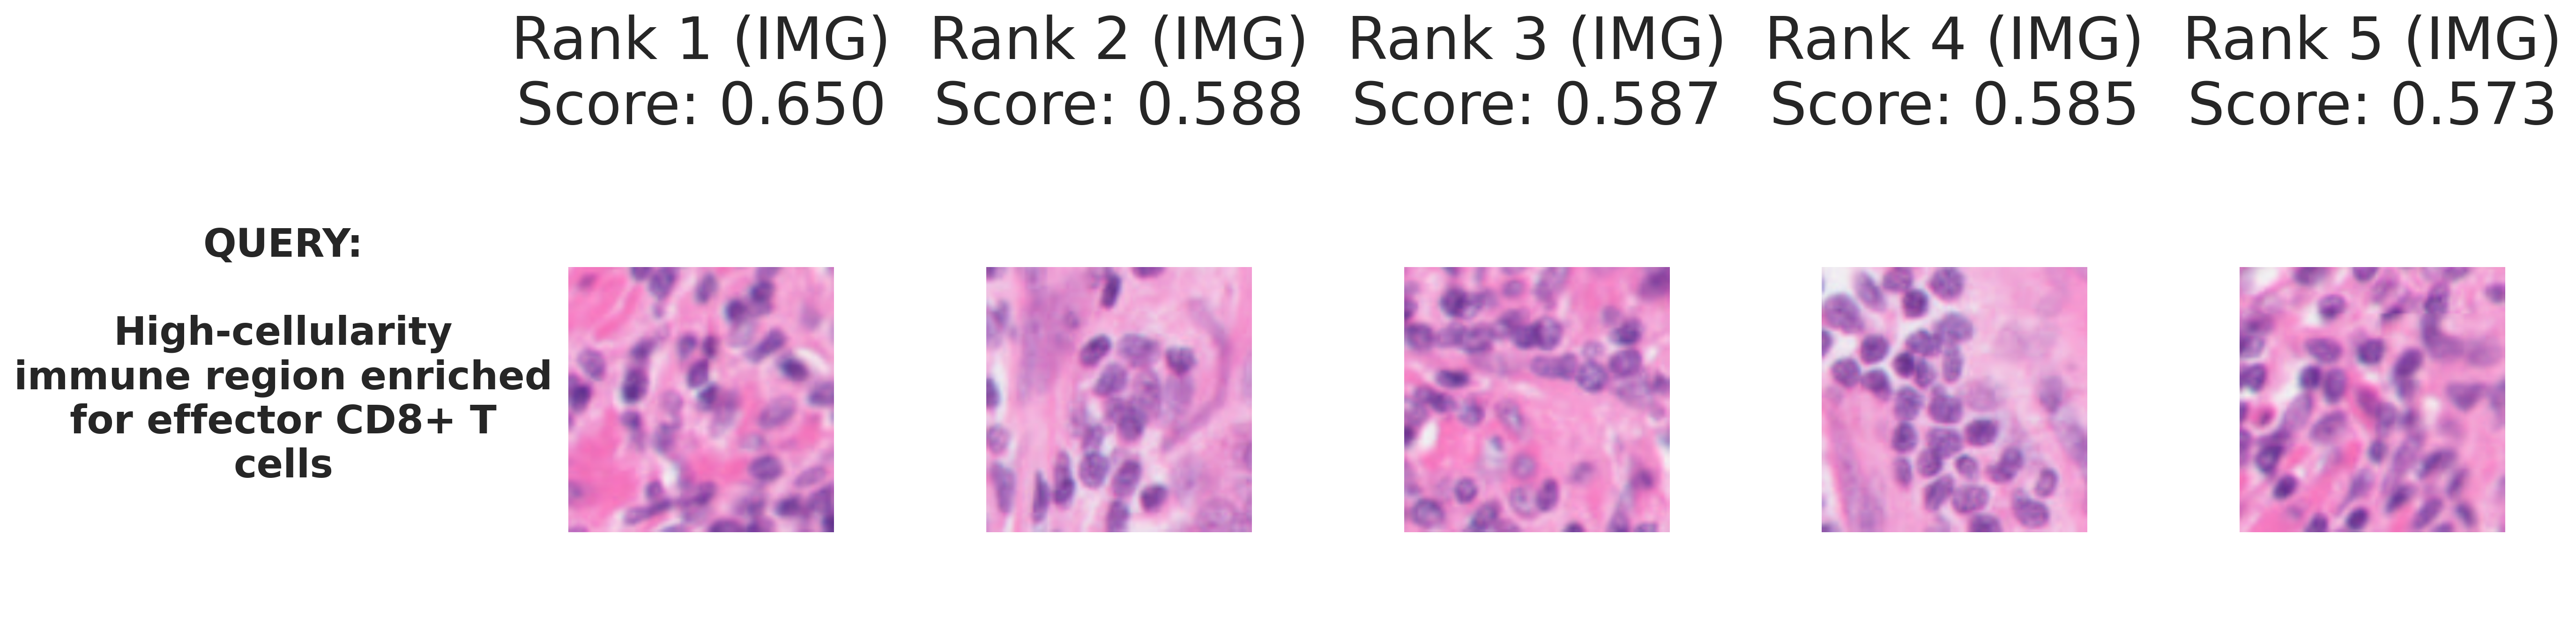

In [56]:
gt_dict_prostate_query = visualize_text_search(
    client, 
    target_model_prostate, 
    "High-cellularity immune region enriched for effector CD8+ T cells", 
    H_img_target_fold_prostate,
    meta_df_target_fold_prostate['unique_key'].tolist(),
    meta_df_target_fold_prostate, 
    prostate_dir, 
    ground_truth_level=ground_truth_openai_dict_prostate["level_1_2_3"],
    sample_id_col="tissue",
    target_modality="img",
    k=5, 
    microns_size=224,
    save_path=figures_dir
)

Let's check the ground truth composition of the retrieved patches (not used for retrieving - just for validation)

In [62]:
def parse_composition(level_1):
    text = (
        level_1
        .replace("COMPOSITION_DATA:", "")
        .strip()
        .rstrip(".")
    )

    composition = {}

    for item in text.split(", "):
        match = re.match(r"(.+)\((\d+)\)$", item)

        if match is None:
            continue

        cell_type = match.group(1).strip()
        count = int(match.group(2))

        composition[cell_type] = count

    return composition

def parse_density(level_3):
    match = re.search(
        r":\s*(\d+)\s*cells,\s*([0-9.]+)\s*percentile\]",
        level_3,
    )

    if match is None:
        raise ValueError(f"Could not parse density: {level_3}")

    return {
        "total_cells": int(match.group(1)),
        "density_percentile": float(match.group(2)),
    }

In [78]:
with open(f"{prostate_dir}/reports_per_patch.pkl", "rb") as f:
    patch_reports_prostate = pickle.load(f)

retrieved_keys = list(gt_dict_prostate_query.keys())

rows = []

for retrieval_rank, key in enumerate(retrieved_keys, start=1):
    report = patch_reports_prostate[key]

    composition = parse_composition(report["level_1"])
    density = parse_density(report["level_3"])

    ranked_cell_types = list(composition.keys())

    effector_cd8_positions = [
        i + 1
        for i, cell_type in enumerate(ranked_cell_types)
        if "cd8" in cell_type.lower()
        and "effector" in cell_type.lower()
    ]

    effector_cd8_count = sum(
        count
        for cell_type, count in composition.items()
        if "cd8" in cell_type.lower()
        and "effector" in cell_type.lower()
    )

    first_effector_cd8_rank = (
        min(effector_cd8_positions)
        if effector_cd8_positions
        else None
    )

    rows.append({
        "Retrieval rank": retrieval_rank,
        "Density percentile": density["density_percentile"],
        "Effector CD8+ abundance rank": first_effector_cd8_rank,
        "Effector CD8+ cells": effector_cd8_count,
    })

query_validation_df = pd.DataFrame(rows)

In [79]:
query_validation_df

,Retrieval rank,Density percentile,Effector CD8+ abundance rank,Effector CD8+ cells
0,1,0.99,2,16
1,2,0.95,4,3
2,3,0.99,1,9
3,4,0.98,3,5
4,5,1.00,2,9


Let's also get the ground truth text descriptions (not used for retrieval).

In [80]:

print(gt_dict_prostate_query)

{'PCA007__patch_x15478_y4858': 'A T cell-enriched region is characterized by dominant effector CD8+ T cells expressing CCL4, CXCR4, and CCL5, along with interferon-responsive CXCL9-positive T cells. Secondary populations include CD4+ T cells, regulatory T cells expressing CTLA4 and FOXP3, naive T cells, and a minor dendritic cell subset. The interaction pattern is primarily characterized by immune–immune contacts. T cells expressing IFN response genes interact with themselves via CXCL9-HLADRA, and CD4 T cells engage with each other through CXCR4. The tissue exhibits high cellularity with a packed, high-density architecture in the 99th percentile. The cellular composition is predominantly T-cell subsets, indicating a T-cell effector and immune activation-biased environment.', 'PCA007__patch_x10550_y19642': 'A T cell–rich environment is dominated by interferon response–associated CXCL9-expressing T cells, with significant populations of follicular helper–like B cells expressing CXCL13 an

We searched strictly within the held-out test space of the selected fold. The retrieved patches broadly match the query: all five correspond to high-cellularity patches with paired ST annotations consistently showing prominent effector CD8+ T-cell populations.

We will now randomly select a patch to demonstrate the Img<->RNA retrieval.

3724
match_key - PCA010__patch_x22870_y17049, query_key - PCA010__patch_x22870_y18169
match_key - PCA010__patch_x22870_y18169, query_key - PCA010__patch_x22870_y18169
match_key - PCA010__patch_x20854_y16825, query_key - PCA010__patch_x22870_y18169
match_key - PCA010__patch_x23094_y15033, query_key - PCA010__patch_x22870_y18169
match_key - PCA010__patch_x22646_y16601, query_key - PCA010__patch_x22870_y18169


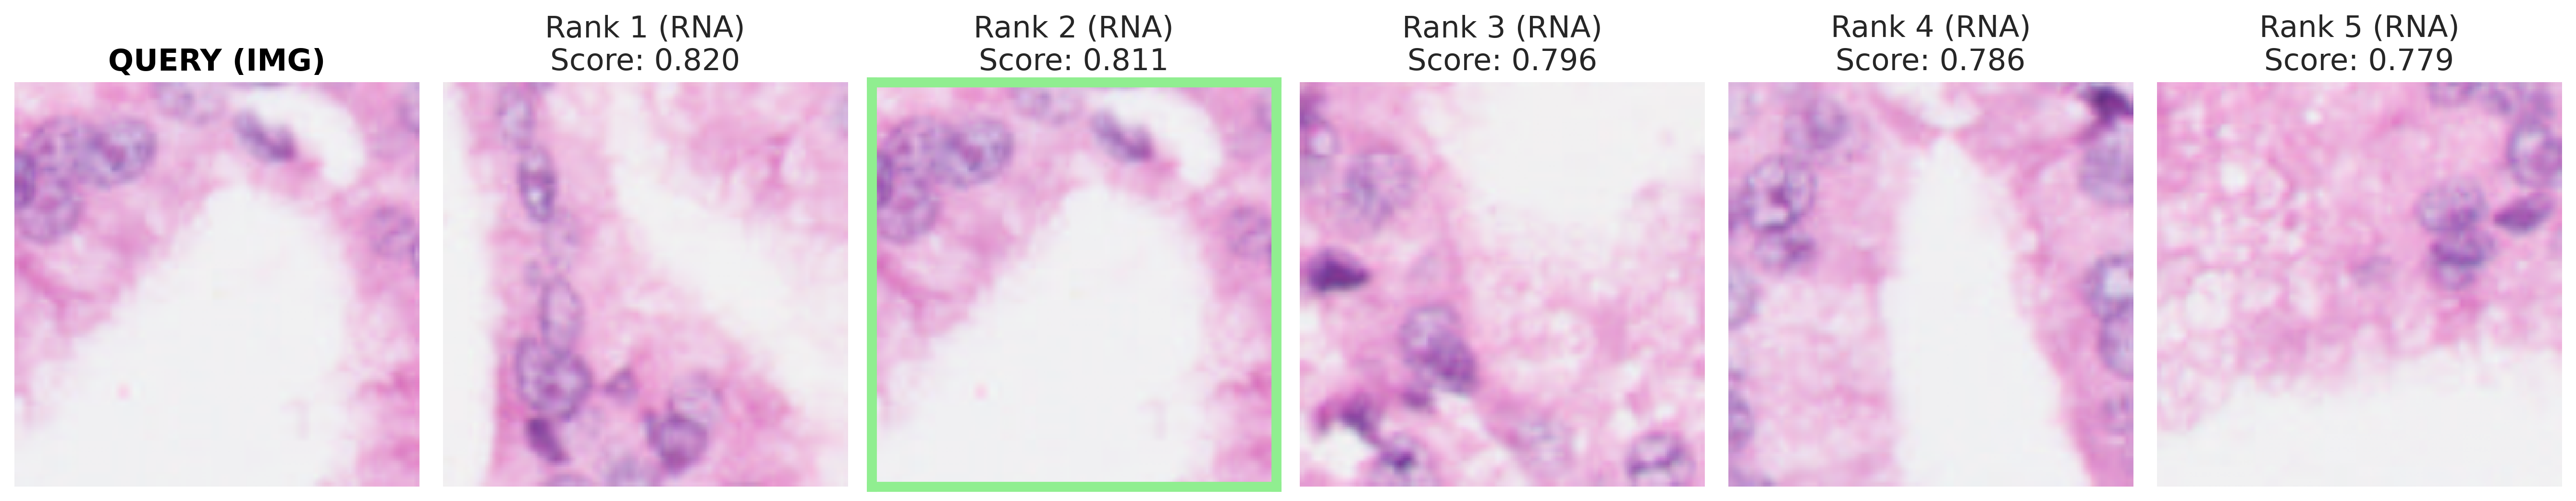

In [123]:
random_query_index = random.randint(0, len(meta_df_target_fold_prostate)-1)
print(random_query_index)

# Given it's morphological patch (img) wer are going to try to retrieve corresponding patches in the transcriptomics modality.
visualize_search_by_example(
    query_idx=random_query_index,
    query_modality="img",
    target_modality="rna",
    query_emb_matrix=H_rna_target_fold_prostate,
    target_emb_matrix=H_img_target_fold_prostate,
    keys=meta_df_target_fold_prostate['unique_key'].tolist(),
    meta_df=meta_df_target_fold_prostate,
    images_root=prostate_dir,
    sample_id_col="tissue",
    k=5,
    microns_size=224,
    save_path=f"{figures_dir}/prostate_search_img2rna"
)

As evident the model retrieved highly similar patches to the query (second retrieved is actually the corresponding query img).

# Performance plot

Finally let's plot the performance across folds for both datasets.

In [30]:
def plot_multimodal_violins(
    lopo_results,
    kfold_results,
    metric="R@10",
    save_path=None,
):
    plot_data = []

    modality_pairs = {
        "Image<–>RNA": ("image_rna", "rna_image"),
        "Image<–>Text": ("image_text", "text_image"),
        "RNA<–>Text": ("rna_text", "text_rna"),
    }

    def add_bidirectional_scores(results, dataset_name):
        for unit_key, metrics in results.items():
            for modality, (forward_key, reverse_key) in modality_pairs.items():

                bidirectional_score = np.mean([
                    metrics[forward_key][metric],
                    metrics[reverse_key][metric],
                ])

                plot_data.append({
                    "Dataset": dataset_name,
                    "Modality": modality,
                    "Score": bidirectional_score,
                })

    add_bidirectional_scores(
        kfold_results,
        "Prostate (Spatial CV)",
    )

    add_bidirectional_scores(
        lopo_results,
        "Lung (LOPO)",
    )

    df_plot = pd.DataFrame(plot_data)

    dataset_order = [
        "Prostate (Spatial CV)",
        "Lung (LOPO)",
    ]

    modality_order = [
        "Image<–>RNA",
        "Image<–>Text",
        "RNA<–>Text",
    ]

    # Match ablation figure styling
    colors = {
        "Prostate (Spatial CV)": "#F4A261",
        "Lung (LOPO)": "#D55E00",
    }

    sns.set_theme(style="white", context="paper")

    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 12,
        "axes.labelsize": 14,
        "axes.titlesize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 10.5,
        "figure.dpi": 300,
    })

    fig, ax = plt.subplots(figsize=(6.5, 4.0))

    sns.violinplot(
        data=df_plot,
        x="Modality",
        y="Score",
        hue="Dataset",
        order=modality_order,
        hue_order=dataset_order,
        palette=colors,
        inner="quart",
        linewidth=0.9,
        cut=0,
        density_norm="width",
        ax=ax,
    )

    # Remove violin outlines for the cleaner ablation style
    for artist in ax.findobj(matplotlib.collections.PolyCollection):
        artist.set_edgecolor("none")

    sns.stripplot(
        data=df_plot,
        x="Modality",
        y="Score",
        hue="Dataset",
        order=modality_order,
        hue_order=dataset_order,
        dodge=True,
        jitter=0.15,
        palette={
            "Prostate (Spatial CV)": "black",
            "Lung (LOPO)": "black",
        },
        size=2.8,
        alpha=0.28,
        ax=ax,
        legend=False,
    )

    ax.set_ylabel(metric)
    ax.set_xlabel("")
    ax.set_ylim(0, 1.05)

    ax.grid(
        axis="y",
        color="0.92",
        linewidth=0.8,
    )
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles,
        labels,
        title=None,
        loc="lower right",
        frameon=False,
        fontsize=10.5,
    )

    plt.tight_layout()

    if save_path:
        fig.savefig(
            f"{save_path}.pdf",
            format="pdf",
            bbox_inches="tight",
        )
        fig.savefig(
            f"{save_path}.svg",
            format="svg",
            bbox_inches="tight",
        )
        fig.savefig(
            f"{save_path}.png",
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

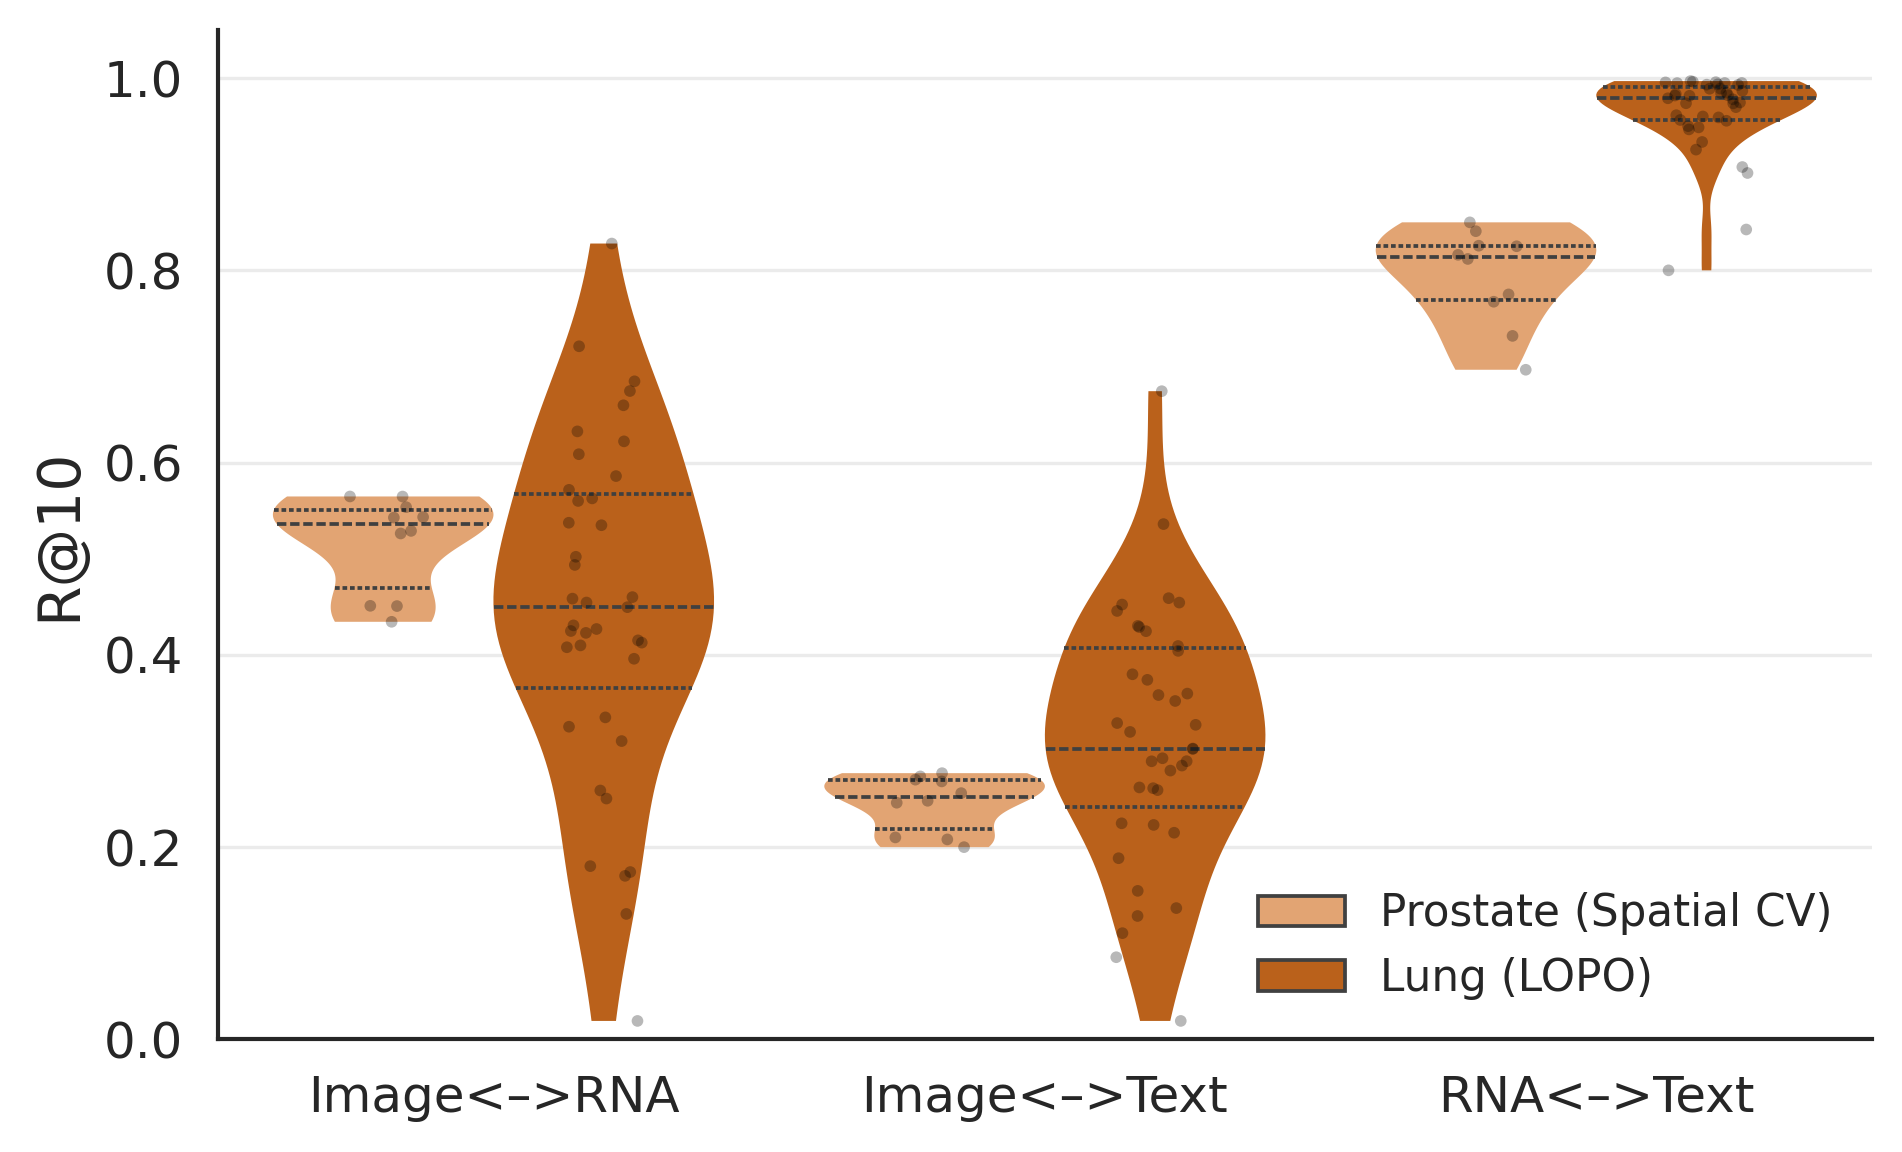

In [31]:
plot_multimodal_violins(
    results_lopo_lung, 
    kfold_results_prostate, 
    metric="R@10",
    save_path=f"{figures_dir}/validation_plot_both_datasets"
)